# PyTorch Custom Datasets

(Date - 28/May/2026)

## 0. Importing torch and setting up device agnostic code

In [73]:
import torch
from torch import nn
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, dataset, Dataset
import requests
import zipfile
from pathlib import Path
import os
import random
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Dict, List
import torchinfo
from torchinfo import summary
from tqdm.auto import tqdm
from timeit import default_timer as Timer
import matplotlib.pyplot as plt
import pandas as pd

device = "cuda" if torch.cuda.is_available() else "cpu"

## 1. Getting the data

In [ ]:
data_path = Path("FoodData/")
image_path = data_path / "pizza_steak_sushi"

if image_path.is_dir():
    print(f"{image_path} directory already exists. No need for downloading")
else:
    print(f"{image_path} does not exist, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)

    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print(f"downloading pizza, steak and sushi data...")
        f.write(request.content)

    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print(f"Unzipping pizza, steak and sushi data...")
        zip_ref.extractall(image_path)


FoodData\pizza_steak_sushi directory already exists. No need for downloading


## 2. Becoming one with the data

### 2.1 Walking through our directories

In [3]:
def walk_through_dir(dir_path):
    for dir_path, dirname, filenames in os.walk(dir_path):
        print(f"There are {len(dirname)} directories and {len(filenames)} images in '{dir_path}'")

In [4]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'FoodData\pizza_steak_sushi'
There are 3 directories and 0 images in 'FoodData\pizza_steak_sushi\test'
There are 0 directories and 25 images in 'FoodData\pizza_steak_sushi\test\pizza'
There are 0 directories and 19 images in 'FoodData\pizza_steak_sushi\test\steak'
There are 0 directories and 31 images in 'FoodData\pizza_steak_sushi\test\sushi'
There are 3 directories and 0 images in 'FoodData\pizza_steak_sushi\train'
There are 0 directories and 78 images in 'FoodData\pizza_steak_sushi\train\pizza'
There are 0 directories and 75 images in 'FoodData\pizza_steak_sushi\train\steak'
There are 0 directories and 72 images in 'FoodData\pizza_steak_sushi\train\sushi'


### 2.2 Setting up train and test paths

In [5]:
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(WindowsPath('FoodData/pizza_steak_sushi/train'),
 WindowsPath('FoodData/pizza_steak_sushi/test'))

### 2.3 Visualizing our images

Random image path: FoodData\pizza_steak_sushi\train\steak\421476.jpg
Image class: steak
Image height: 512
Image width: 512


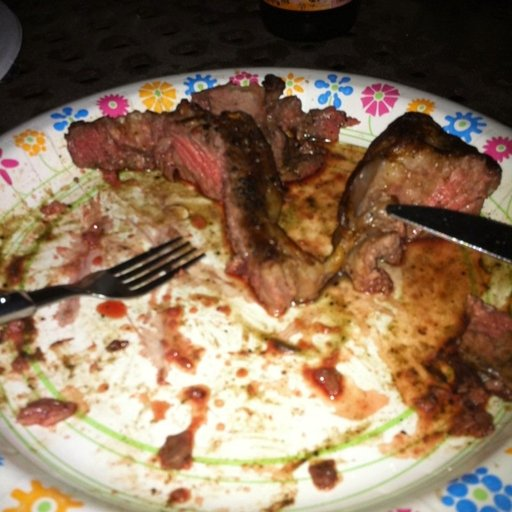

In [6]:
image_path_list = list(image_path.glob("*/*/*.jpg"))

random_image_path = random.choice(image_path_list)

image_class = random_image_path.parent.stem

img = Image.open(random_image_path)

print(F"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

### 2.4 Plotting our image with matplotlib

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

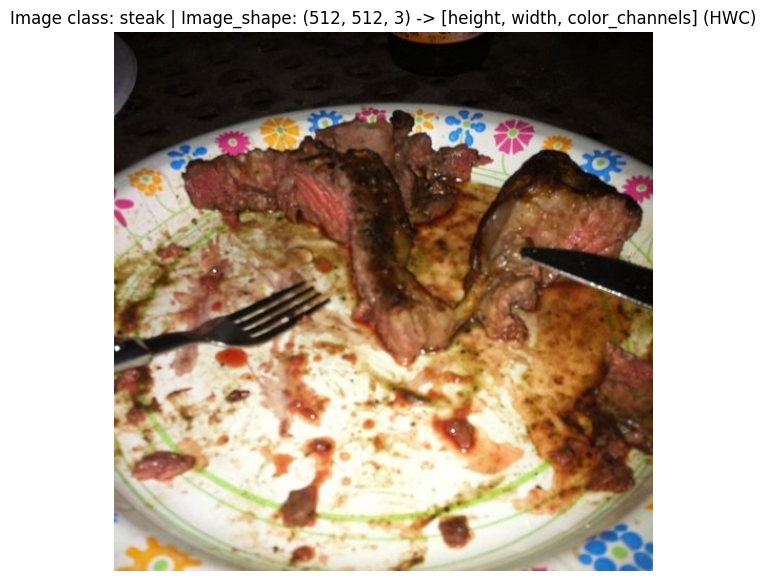

In [7]:
image_as_array = np.asarray(img)

plt.figure(figsize=(10,7))
plt.imshow(image_as_array)
plt.title(f"Image class: {image_class} | Image_shape: {image_as_array.shape} -> [height, width, color_channels] (HWC)")
plt.axis(False)

## 3. Transforming data

(Date - 29/May/2026)

### 3.1 Transforming data with `torchvision.transforms`

In [8]:
data_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

In [9]:
data_transform(img).shape

torch.Size([3, 64, 64])

In [10]:
def plot_transformed_image(image_paths, transform, n=3, seed=None):
    """Plots a series of random images from image_paths.

    Will open n image paths from image_paths, transform them
    with transform and plot them side by side.

    Args:
        image_paths (list): List of target image paths. 
        transform (PyTorch Transforms): Transforms to apply to images.
        n (int, optional): Number of images to plot. Defaults to 3.
        seed (int, optional): Random seed for the random generator. Defaults to 42.
    """

    if seed:
        random.seed(seed)
    random_image_paths = random.sample(image_paths, k=n)

    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(nrows=1, ncols=2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original\nSize:: {f.size}")
            ax[0].axis(False)

            transformed_image = transform(f).permute(1,2,0) # (C, H, W) -> (H, C, W)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed\nShape: {transformed_image.shape}")
            ax[1].axis("off") # you may also write False instead of off

            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

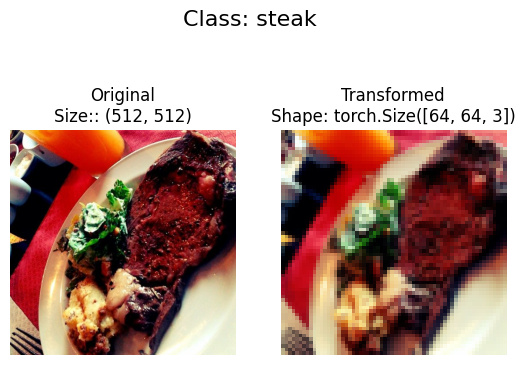

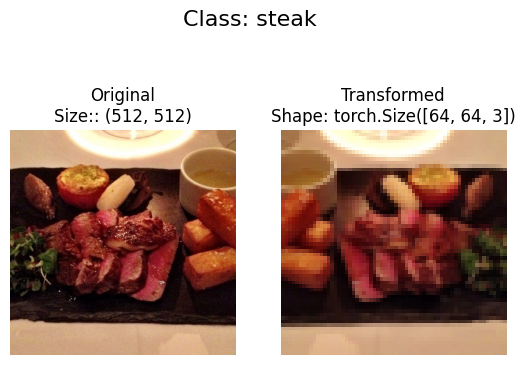

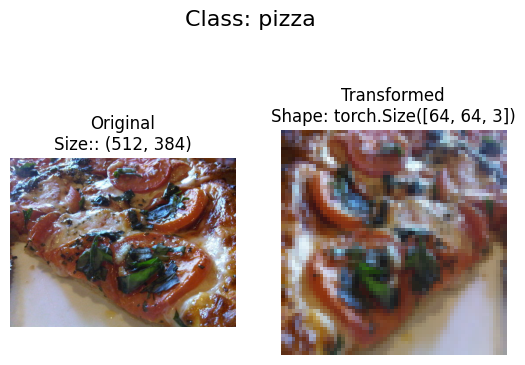

In [11]:
plot_transformed_image(image_paths=image_path_list,
                       transform=data_transform,
                       n=3,
                       seed=None)

(Date - 30/May/2026)

## 4. Option 1: Loading image data using `ImageFolder`

In [12]:
train_data = datasets.ImageFolder(root=train_dir,
                                  transform=data_transform,
                                  target_transform=None)

test_data = datasets.ImageFolder(root=test_dir,
                                 transform=data_transform)

train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: FoodData\pizza_steak_sushi\train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: FoodData\pizza_steak_sushi\test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [13]:
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [14]:
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [15]:
len(train_data), len(test_data)

(225, 75)

In [16]:
train_data.samples[0]

('FoodData\\pizza_steak_sushi\\train\\pizza\\1008844.jpg', 0)

In [17]:
img, label = train_data[0][0], train_data[0][1]
print(f"image tensor:\n{img}\n")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label} ({class_names[label]})")
print(f"Label datatype {type(label)}")

image tensor:
tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
         [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
         [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
         ...,
         [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
         [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
         [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],

        [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
         [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
         [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
         ...,
         [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
         [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
         [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],

        [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
         [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
         [0.0196, 0.0157, 0.0157,  ..., 0.09

In [18]:
class_names[label]

'pizza'

Original shape: torch.Size([3, 64, 64]) -> [Color Channels, Height, width]
image permute: torch.Size([64, 64, 3]) -> [Height, Width, Color Channels]


Text(0.5, 1.0, 'pizza')

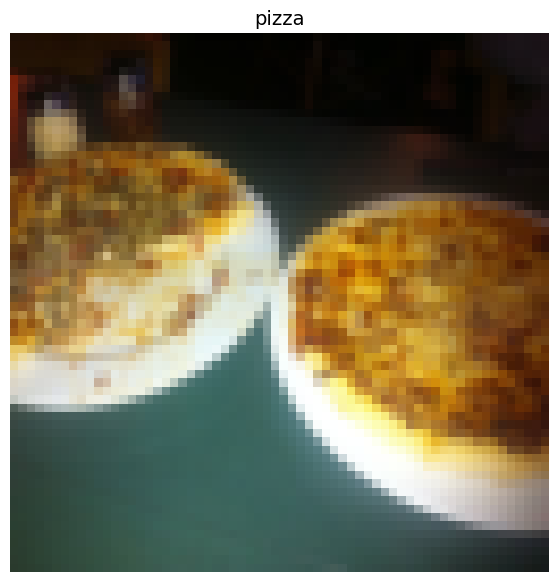

In [19]:
img_permute = img.permute(1,2,0)

print(f"Original shape: {img.shape} -> [Color Channels, Height, width]")
print(f"image permute: {img_permute.shape} -> [Height, Width, Color Channels]")

plt.figure(figsize=(10,7))
plt.imshow(img_permute)
plt.axis("OFF")
plt.title(class_names[label], fontsize=14)

### 4.1 Preparing Data Loader

In [20]:
BATCH_SIZE = 1
train_dataloader = DataLoader(dataset=train_data,
                              shuffle=True,
                              num_workers=1, # You may also write : num_workers = os.cpu_count()
                              batch_size=BATCH_SIZE)

test_dataloader = DataLoader(dataset=test_data,
                              shuffle=False,
                              num_workers=1,
                              batch_size=BATCH_SIZE)

len(train_dataloader), len(test_dataloader)

(225, 75)

In [21]:
img, label = next(iter(train_dataloader))

print(f"Train Image shape: {img.shape} -> [color channels, height width]")
print(f"Label shape: {label.shape}")

Train Image shape: torch.Size([1, 3, 64, 64]) -> [color channels, height width]
Label shape: torch.Size([1])


## 5. Option 2: Loading Image Data with a Custom `Dataset`

(Date - 31/May/2026)

In [22]:
train_data.classes, train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 5.1 Creating a helper function to get class names

We want a function to:
1. Get the class name using `os.scandir()` to transverse a target dictionary (ideally the directory is in standard image classification format).
2. Raise an error if the class names aren't found.
3. Turn the classes names into a dict and a list, and return them.

In [23]:
target_directory = train_dir
print(f"Target dir: {target_directory}")

class_names_found = sorted([entry.name for entry in list(os.scandir(target_directory))])
class_names_found

Target dir: FoodData\pizza_steak_sushi\train


['pizza', 'steak', 'sushi']

In [24]:
os.scandir(target_directory)

In [25]:
list(os.scandir(target_directory))

[<DirEntry 'pizza'>, <DirEntry 'steak'>, <DirEntry 'sushi'>]

In [26]:
for entry in list(os.scandir(target_directory)):
    print(entry,"\t", entry.name,"\t", entry.__class__)

<DirEntry 'pizza'> 	 pizza 	 <class 'nt.DirEntry'>
<DirEntry 'steak'> 	 steak 	 <class 'nt.DirEntry'>
<DirEntry 'sushi'> 	 sushi 	 <class 'nt.DirEntry'>


In [27]:
def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:
    """Finds the class folder names in a target directory.
    
    Assumes target directory is in standard image classification format.

    Args:
        directory (str): target directory to load class names from.

    Returns:
        Tuple[List[str], Dict[str, int]]: (list_of_class_names, dict(class_name: idx...))
    
    Example:
        find_classes("food_images/train")
         (["class_1", "class_2"], {"class_1": 0, ...})

    """
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())

    if not classes:
        raise FileNotFoundError(f"Couldn't find any classes in {directory}... Please check file structure")
    
    class_to_idx = {class_name: i for i, class_name in enumerate(classes)}

    return classes, class_to_idx

In [28]:
find_classes(directory=target_directory)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 5.2 Create a custom `Dataset` to replicate `ImageFolder`

To create our own custom dataset, we will have to:
1. Subclass torch.utils.data.Dataset.
2. Initialize our subclass with a targ_dir parameter (the target data directory) and transform parameter (so we have the option to transform our data if needed).
3. Create several attributes for paths (the paths of our target images), transform (the transforms we might like to use, this can be None), classes and class_to_idx (from our find_classes() function).
4. Create a function to load images from file and return them, this could be using PIL or torchvision.io (for input/output of vision data).
5. Overwrite the __len__ method of torch.utils.data.Dataset to return the number of samples in the Dataset, this is recommended but not required. This is so you can call len(Dataset).
6. Overwrite the __getitem__ method of torch.utils.data.Dataset to return a single sample from the Dataset, this is required.

(Date - 1/June/2026)

In [29]:
class ImageFolderCustom(Dataset):
    def __init__(self,
               targ_dir:str,
               transform=None):
        
        self.paths = list(Path(targ_dir).glob("*/*.jpg"))
        self.transform = transform
        self.classes, self.class_to_idx = find_classes(targ_dir)

    def load_image(self, index:int) -> Image.Image:
        image_path = self.paths[index]
        return Image.open(image_path)

    def __len__(self) -> int:
        return len(self.paths)
    
    def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
        img = self.load_image(index)
        class_name = self.paths[index].parent.name
        class_idx = self.class_to_idx[class_name]

        if self.transform:
            return self.transform(img), class_idx
        else:
            return img, class_idx

In [30]:
train_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])

In [31]:
train_data_custom = ImageFolderCustom(targ_dir=train_dir,
                  transform=train_transform)

test_data_custom = ImageFolderCustom(targ_dir=test_dir,
                                     transform=test_transform)

In [32]:
train_data_custom, test_data_custom

(<__main__.ImageFolderCustom at 0x2d55afa7e50>,
 <__main__.ImageFolderCustom at 0x2d57489fb10>)

In [33]:
len(train_data), len(train_data_custom)

(225, 225)

In [34]:
train_data_custom.classes

['pizza', 'steak', 'sushi']

In [35]:
train_data_custom.class_to_idx

{'pizza': 0, 'steak': 1, 'sushi': 2}

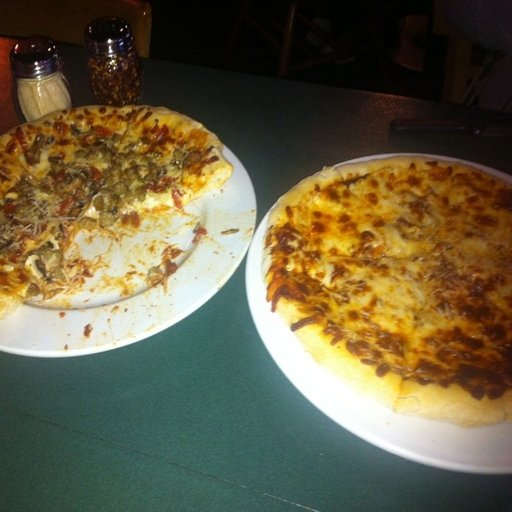

In [36]:
train_data_custom.load_image(index=0)

In [37]:
print(train_data_custom.classes == train_data.classes)
print(train_data_custom.class_to_idx == train_data.class_to_idx)

True
True


### 5.3 Creating a function to display random images

(Date - 2/Jun/2026)

In [38]:
def display_random_images(dataset: torch.utils.data.Dataset,
                          classes: List[str]=None,
                          n: int = 10,
                          display_shape: bool = True,
                          seed: int = None):
    
    if n>10:
        n = 10
        display_shape = False
        print(f"For display purpose, n shouldn't be larger than 10, setting to 10 and removing shape display...")

    if seed:
        random.seed(seed)
    
    random_samples_idx = random.sample(range(len(dataset)), k=n)

    plt.figure(figsize=(16,8))

    for i, targ_sample in enumerate(random_samples_idx):
        targ_img, targ_label = dataset[targ_sample][0], dataset[targ_sample][1]

        targ_image_adjust = targ_img.permute(1,2,0)

        plt.subplot(1, n, i+1)
        plt.imshow(targ_image_adjust)
        plt.axis("off")
        if classes:
            title = f"Class: {classes[targ_label]}"
            if display_shape:
                title = title + f"\nshape: {targ_image_adjust.shape}"
        plt.title(title)

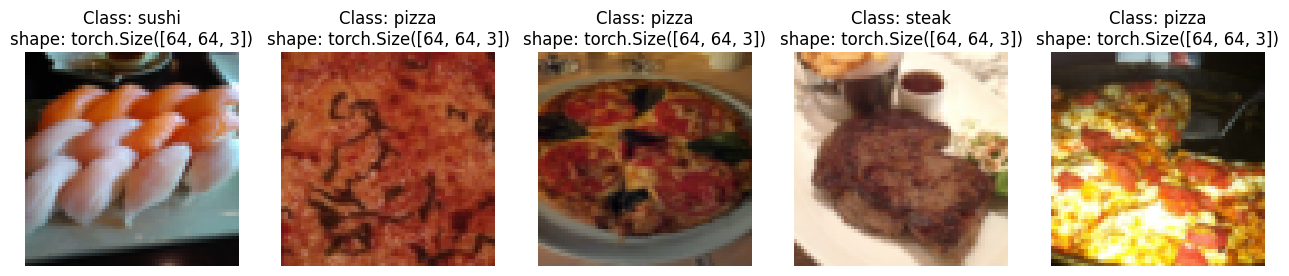

In [39]:
display_random_images(train_data,
                      n=5,
                      classes=class_names,
                      display_shape=True,
                      seed=None)

For display purpose, n shouldn't be larger than 10, setting to 10 and removing shape display...


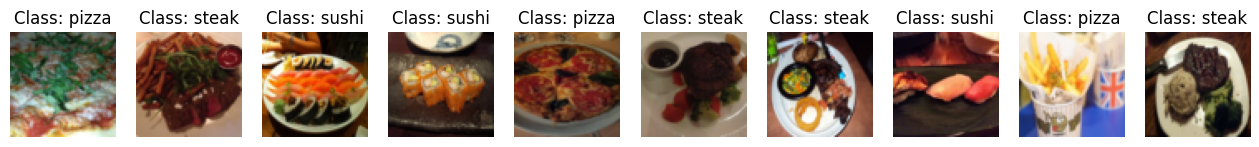

In [40]:
display_random_images(train_data_custom,
                      n=20,
                      classes=class_names,
                      seed=None)

### 5.4 Turn custom loaded images into `DataLoaders.`

(Date - 3/June/2026)

In [41]:
BATCH_SIZE = 1
train_dataloader_custom = DataLoader(dataset=train_data_custom,
                              num_workers=0,
                              shuffle=True,
                              batch_size=BATCH_SIZE)

test_dataloader_custom = DataLoader(dataset=test_data_custom,
                              num_workers= 0, # cpu count = 1
                              shuffle=True,
                              batch_size=BATCH_SIZE)

train_dataloader_custom, test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x2d5749c84d0>,
 <torch.utils.data.dataloader.DataLoader at 0x2d571a12110>)

In [42]:
img_custom, label_custom = next(iter(train_dataloader_custom))

img_custom.shape, label_custom.shape

(torch.Size([1, 3, 64, 64]), torch.Size([1]))

## 6. Other forms of transforms (data augmentation)

(Date - 4/June/2026)

Data augmentation is the process of artificially adding diversity to your training data.

### 6.1 Trivial augment

In [43]:
train_transform = transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.ToTensor()
    ])

In [44]:
image_path_list = list(image_path.glob("*/*/*.jpg"))
image_path_list[:10]

[WindowsPath('FoodData/pizza_steak_sushi/test/pizza/1152100.jpg'),
 WindowsPath('FoodData/pizza_steak_sushi/test/pizza/1503858.jpg'),
 WindowsPath('FoodData/pizza_steak_sushi/test/pizza/1687143.jpg'),
 WindowsPath('FoodData/pizza_steak_sushi/test/pizza/1925494.jpg'),
 WindowsPath('FoodData/pizza_steak_sushi/test/pizza/194643.jpg'),
 WindowsPath('FoodData/pizza_steak_sushi/test/pizza/195160.jpg'),
 WindowsPath('FoodData/pizza_steak_sushi/test/pizza/2003290.jpg'),
 WindowsPath('FoodData/pizza_steak_sushi/test/pizza/2019408.jpg'),
 WindowsPath('FoodData/pizza_steak_sushi/test/pizza/2111981.jpg'),
 WindowsPath('FoodData/pizza_steak_sushi/test/pizza/2124579.jpg')]

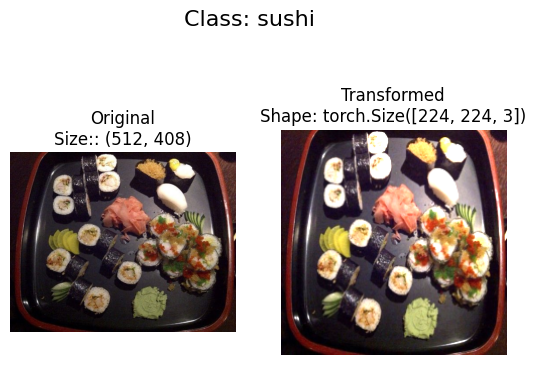

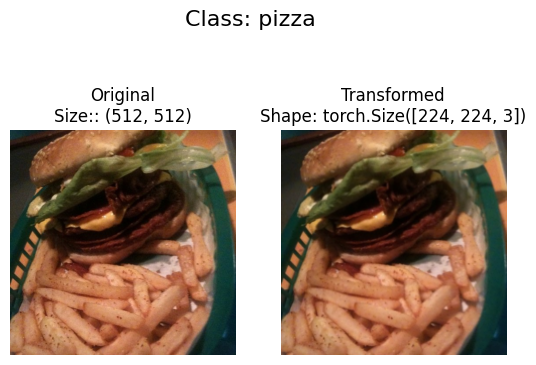

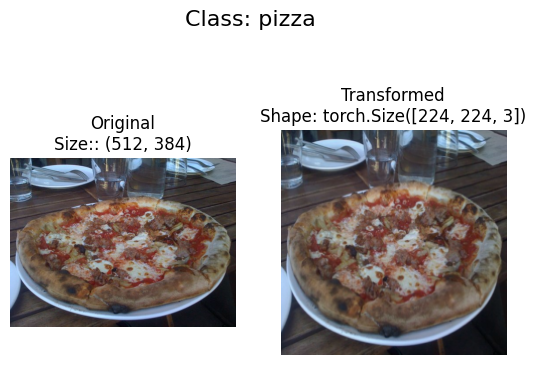

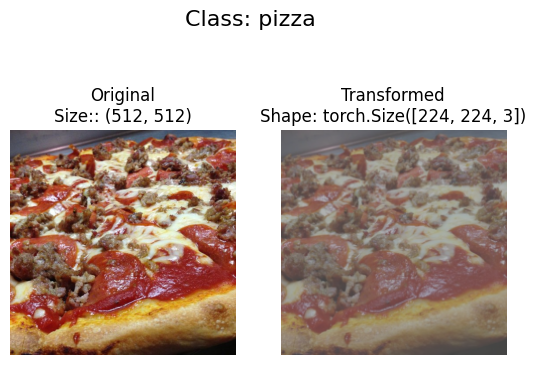

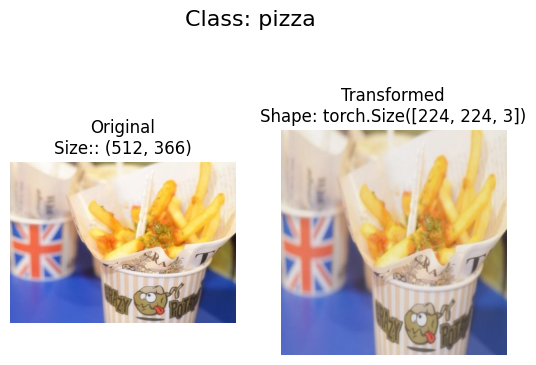

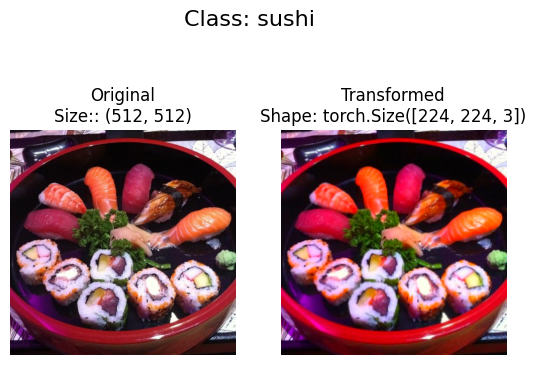

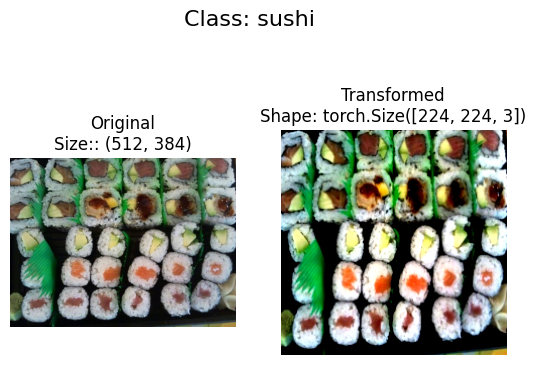

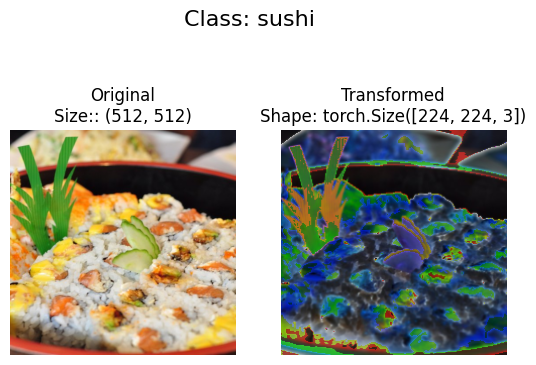

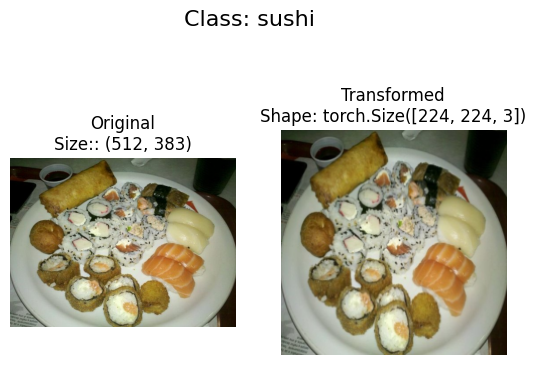

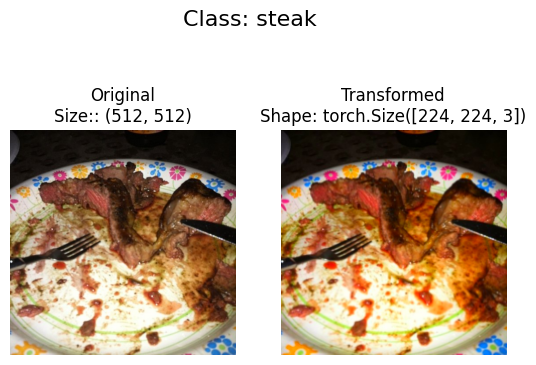

In [45]:
plot_transformed_image(
    image_paths = image_path_list,
    transform=train_transform,
    n=10,
    seed=42
)

## 7. Model 0: Tiny VGG without data augmentation

(Date - 5/June/2026)

### 7.1 Creating transforms and loading data for model 0

In [46]:
simple_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])

In [47]:
train_data_simple = datasets.ImageFolder(root=train_dir,
                                         transform=simple_transform)

test_data_simple = datasets.ImageFolder(root=test_dir,
                                        transform=simple_transform)

BATCH_SIZE = 32
NUM_WORKERS = 0

train_dataloader_simple = DataLoader(dataset=train_data_simple,
                                     batch_size=BATCH_SIZE,
                                    shuffle=True,
                                    num_workers=NUM_WORKERS)

test_dataloader_simple = DataLoader(dataset=test_data_simple,
                                    batch_size=BATCH_SIZE,
                                    shuffle=False,
                                    num_workers=NUM_WORKERS)

### 7.2 Create a Tiny VGG model class

In [48]:
class TinyVGG(nn.Module):
    def __init__(self,
                 input_shape: int,
                 hidden_units: int,
                 output_shape: int) -> None:
    
        super().__init__()

        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1
                      ),
            nn.ReLU(),
            nn.Tanh(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1
                      ),
            nn.ReLU(),
            nn.Tanh(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2)
                      )
        

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1
                      ),
            nn.ReLU(),
            nn.Tanh(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1
                      ),
            nn.ReLU(),
            nn.Tanh(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2)
                      )
        
        self.conv_block_3 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1
                      ),
            nn.ReLU(),
            nn.Tanh(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1
                      ),
            nn.ReLU(),
            nn.Tanh(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2)
                      )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*64,
                      out_features=output_shape)
        )
    
    def forward(self, x):
        x = self.conv_block_1(x)
        # print(x.shape)
        x = self.conv_block_2(x)
        # print(x.shape)
        x = self.conv_block_3(x)
        # print(x.shape)
        x = self.classifier(x)
        return x

In [49]:
16*16

256

In [50]:
torch.manual_seed(42)
model_0 = TinyVGG(input_shape=3,
                  hidden_units=20,
                  output_shape=len(class_names)).to(device) # len(class_names) = 3

model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Tanh()
    (3): Conv2d(20, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): Tanh()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(20, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Tanh()
    (3): Conv2d(20, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): Tanh()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_3): Sequential(
    (0): Conv2d(20, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Tanh()
    (3): Conv2d(20, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): Tanh()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)


### 7.3 Try a forward pass on a single image (to test the model)

In [51]:
image_batch, label_batch = next(iter(train_dataloader_simple))
image_batch.shape, label_batch.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [52]:
model_0(image_batch).to(device)

tensor([[ 0.0015, -0.0100,  0.0158],
        [ 0.0022, -0.0105,  0.0153],
        [ 0.0023, -0.0104,  0.0155],
        [ 0.0020, -0.0102,  0.0160],
        [ 0.0022, -0.0101,  0.0157],
        [ 0.0019, -0.0106,  0.0155],
        [ 0.0023, -0.0105,  0.0154],
        [ 0.0028, -0.0105,  0.0154],
        [ 0.0028, -0.0106,  0.0153],
        [ 0.0019, -0.0101,  0.0159],
        [ 0.0020, -0.0101,  0.0158],
        [ 0.0022, -0.0102,  0.0156],
        [ 0.0024, -0.0103,  0.0157],
        [ 0.0022, -0.0106,  0.0154],
        [ 0.0021, -0.0104,  0.0156],
        [ 0.0029, -0.0104,  0.0154],
        [ 0.0024, -0.0104,  0.0153],
        [ 0.0017, -0.0100,  0.0160],
        [ 0.0019, -0.0101,  0.0158],
        [ 0.0025, -0.0106,  0.0155],
        [ 0.0015, -0.0099,  0.0161],
        [ 0.0020, -0.0103,  0.0157],
        [ 0.0021, -0.0102,  0.0157],
        [ 0.0024, -0.0105,  0.0156],
        [ 0.0023, -0.0104,  0.0159],
        [ 0.0019, -0.0102,  0.0157],
        [ 0.0023, -0.0103,  0.0159],
 

In [53]:
1280/20

64.0

### 7.4 Using torchinfo to get the summary of our model

In [54]:
summary(model=model_0, input_size=(BATCH_SIZE, 3, 64, 64))

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [32, 3]                   --
├─Sequential: 1-1                        [32, 20, 32, 32]          --
│    └─Conv2d: 2-1                       [32, 20, 64, 64]          560
│    └─ReLU: 2-2                         [32, 20, 64, 64]          --
│    └─Tanh: 2-3                         [32, 20, 64, 64]          --
│    └─Conv2d: 2-4                       [32, 20, 64, 64]          3,620
│    └─ReLU: 2-5                         [32, 20, 64, 64]          --
│    └─Tanh: 2-6                         [32, 20, 64, 64]          --
│    └─MaxPool2d: 2-7                    [32, 20, 32, 32]          --
├─Sequential: 1-2                        [32, 20, 16, 16]          --
│    └─Conv2d: 2-8                       [32, 20, 32, 32]          3,620
│    └─ReLU: 2-9                         [32, 20, 32, 32]          --
│    └─Tanh: 2-10                        [32, 20, 32, 32]          --
│    └─C

### 7.5 Creating train_step and test_step functions

(Date - 6/Jun/2026)

In [55]:
def train_step(model : torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn : torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device=device):
    
    model.train()
    loss, acc = 0, 0

    for batch, (img, label_truth) in enumerate(dataloader):
        img, label_truth = img.to(device), label_truth.to(device)

        label_pred = model(img)

        temp_loss = loss_fn(label_pred, label_truth)
        loss += temp_loss.item()

        optimizer.zero_grad()

        temp_loss.backward()

        optimizer.step()

        label_pred_class = torch.argmax(torch.softmax(label_pred, dim=1), dim=1)
        acc += ((label_pred_class==label_truth).sum().item()/len(label_pred)) * 100

    loss = loss / len(dataloader)
    acc = acc / len(dataloader)
    return loss, acc

In [56]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device=device):
    model.eval()
    loss, acc = 0,0

    with torch.inference_mode():
        for batch, (img, truth_label) in enumerate(dataloader):
            img, truth_label = img.to(device), truth_label.to(device)

            pred_label = model(img)

            temp_loss = loss_fn(pred_label, truth_label)
            loss += temp_loss.item()

            label_pred_class = pred_label.argmax(dim=1)
            acc += ((label_pred_class == truth_label).sum().item()/len(label_pred_class)) * 100
        
    loss = loss / len(dataloader)
    acc = acc / len(dataloader)

    return loss, acc

### 7.6 Creating a training function

In [57]:
def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          loss_fn: torch.nn.Module,
          optimizer: torch.optim.Optimizer,
          epochs: int,
          device=None):
    
       results = {"train_loss" : [],
                  "train_acc" : [],
                  "test_loss" : [],
                  "test_acc" : []}

       for epoch in tqdm(range(epochs)):

              train_loss, train_acc = train_step(
                                                 model=model,
                                                 dataloader=train_dataloader,
                                                 loss_fn=loss_fn,
                                                 optimizer=optimizer,
                              
                                                 )
        
              test_loss, test_acc = test_step(   model=model,
                                                 dataloader=test_dataloader,
                                                 loss_fn=loss_fn,
                                             
                                                 )
              
              print(f"epoch : {epoch + 1} | "
                    f"train_loss : {train_loss:.4f} | "
                    f"train_acc : {train_acc:.2f} | "
                    f"test_loss : {test_loss:.4f} | "
                    f"test_acc : {test_acc:.2f} | ")
              
              results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
              results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
              results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
              results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

       return results

### 7.7 Setting up optimizer and loss function and training our model

In [58]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(params=model_0.parameters(),
                             lr = 0.001)

In [59]:
model_0_start_time = Timer()

model_0_results = train(model=model_0,
      train_dataloader=test_dataloader_simple,
      test_dataloader=test_dataloader_simple,
      loss_fn=loss_fn,
      optimizer=optimizer,
      epochs=5,
      device=device)

model_0_end_time = Timer()
model_0_total_time = model_0_end_time - model_0_start_time

print(f"Total time taken: {model_0_total_time:.3f} seconds")

 20%|██        | 1/5 [00:02<00:09,  2.45s/it]

epoch : 1 | train_loss : 1.1053 | train_acc : 0.00 | test_loss : 1.0930 | test_acc : 26.04 | 


 40%|████      | 2/5 [00:03<00:05,  1.83s/it]

epoch : 2 | train_loss : 1.0885 | train_acc : 26.04 | test_loss : 1.0840 | test_acc : 54.17 | 


 60%|██████    | 3/5 [00:05<00:03,  1.62s/it]

epoch : 3 | train_loss : 1.0782 | train_acc : 54.17 | test_loss : 1.0743 | test_acc : 54.17 | 


 80%|████████  | 4/5 [00:06<00:01,  1.53s/it]

epoch : 4 | train_loss : 1.0670 | train_acc : 54.17 | test_loss : 1.0630 | test_acc : 54.17 | 


100%|██████████| 5/5 [00:08<00:00,  1.63s/it]

epoch : 5 | train_loss : 1.0537 | train_acc : 54.17 | test_loss : 1.0494 | test_acc : 54.17 | 
Total time taken: 8.176 seconds


### 7.8 Plotting the loss curves of Model 0

(Date - 7/June/2026)

In [60]:
model_0_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

In [61]:
def plot_loss_accuracy_curves(results: Dict[str, List[float]]):
    train_loss = results["train_loss"]
    test_loss = results["test_loss"]

    train_accuracy = results["train_acc"]
    test_accuracy = results["test_acc"]

    epochs = range(len(results["train_loss"]))

    plt.figure(figsize = (15,7))
    plt.subplot(1,2,1)
    plt.ticklabel_format(style="plain", axis='y', useOffset=False)
    plt.plot(epochs, train_loss, label = "train_loss")
    plt.plot(epochs, test_loss, label = "test_loss")
    plt.title("Loss curve")
    plt.ylabel("Loss")
    plt.xlabel("Epochs")
    plt.legend()
    print()

    plt.subplot(1,2,2)
    plt.plot(epochs, train_accuracy, label = "train_accuracy")
    plt.plot(epochs, test_accuracy, label = "test_accuracy")
    plt.title("Accuracy curve")
    plt.ylabel("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()


In [62]:
print(model_0_results["train_loss"])

[1.1052686770757039, 1.0885046323140461, 1.0781848033269246, 1.0669776995976765, 1.0536559224128723]


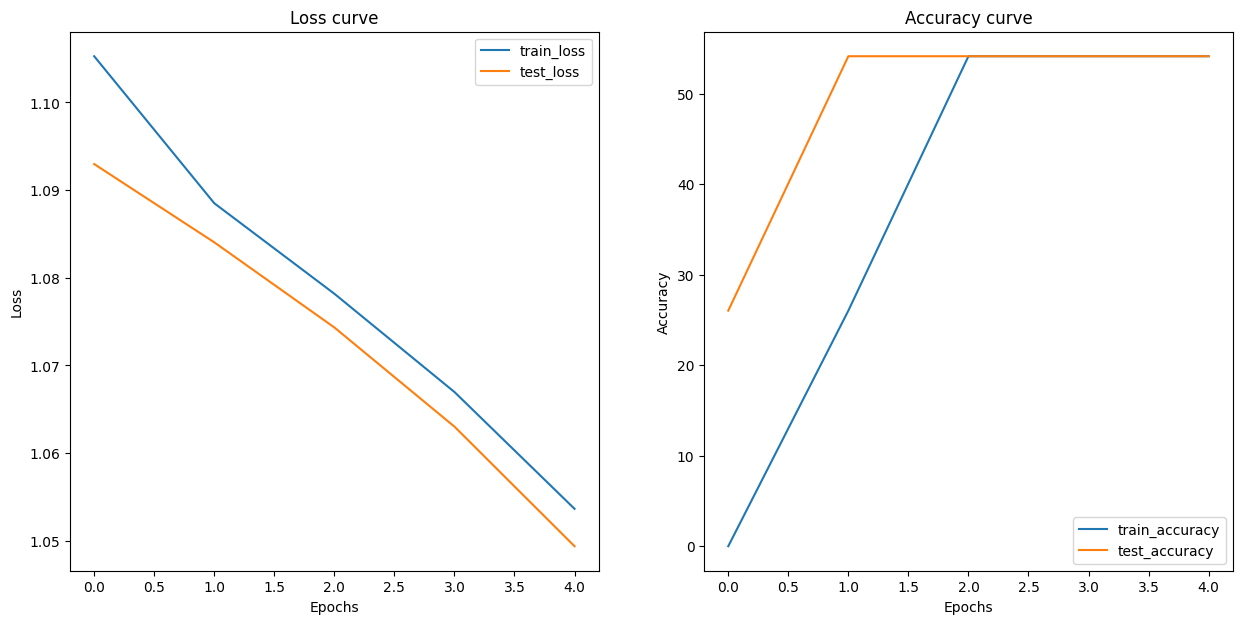

In [63]:
plot_loss_accuracy_curves(model_0_results)

## 8. What should an ideal loss curve look like?

(Date - 8/June/2026)

<img src = "images/3LossCurves.jpg" height="500" width="1500">

[Look at section 8.1 and 8.2 for more.](https://www.learnpytorch.io/04_pytorch_custom_datasets/#81-how-to-deal-with-overfitting)

## 9. Model 1: TinyVGG with Data Augmentation

### 9.1 Creating transform with data augmentation

In [64]:
train_transform_trivial = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

test_transform_simple = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])

### 9.2 Creating a train and test `Dataset`'s and `DataLoader`'s with data augmentation

In [65]:
train_data_augmented = datasets.ImageFolder(root=train_dir,
                                            transform=train_transform_trivial)

test_data_simple = datasets.ImageFolder(root=test_dir,
                                       transform=test_transform_simple)

In [66]:
BATCH_SIZE = 32
NUM_WORKERS = 1

train_dataloader_augmented = DataLoader(dataset=train_data_augmented,
                                      batch_size=BATCH_SIZE,
                                      shuffle=True,
                                      num_workers=NUM_WORKERS)


test_dataloader_simple = DataLoader(dataset=test_data_simple,
                                    batch_size=BATCH_SIZE,
                                    shuffle=False,
                                    num_workers=NUM_WORKERS)

### 9.3 Constructing and training model 1!

Same model architecture but the training data is augmented.

In [67]:
torch.manual_seed(42)
model_1 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(train_data_augmented.classes)).to(device)

model_1

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Tanh()
    (3): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): Tanh()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Tanh()
    (3): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): Tanh()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_3): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Tanh()
    (3): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): Tanh()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)


In [68]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

NUM_EPOCHS = 5

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(params=model_1.parameters(),
                             lr=0.001)

model_1_start_time = Timer()

model_1_results = train(model=model_1,
                        train_dataloader=train_dataloader_augmented,
                        test_dataloader=test_dataloader_simple,
                        loss_fn=loss_fn,
                        optimizer=optimizer,
                        epochs=NUM_EPOCHS,
                        device=device)

model_1_end_time = Timer()

model_1_total_time = model_1_end_time - model_1_start_time

print(f"Total training time for model_1: {model_1_total_time} seconds")



  0%|          | 0/5 [00:00<?, ?it/s]

 20%|██        | 1/5 [00:17<01:08, 17.01s/it]

epoch : 1 | train_loss : 1.1016 | train_acc : 25.00 | test_loss : 1.0982 | test_acc : 26.04 | 


 40%|████      | 2/5 [00:30<00:44, 14.72s/it]

epoch : 2 | train_loss : 1.0919 | train_acc : 42.58 | test_loss : 1.1058 | test_acc : 26.04 | 


...

epoch : 3 | train_loss : 1.0850 | train_acc : 42.58 | test_loss : 1.1236 | test_acc : 26.04 | 


 80%|████████  | 4/5 [00:56<00:13, 13.82s/it]

epoch : 4 | train_loss : 1.1121 | train_acc : 30.47 | test_loss : 1.1383 | test_acc : 26.04 | 


100%|██████████| 5/5 [01:10<00:00, 14.10s/it]

epoch : 5 | train_loss : 1.0856 | train_acc : 42.58 | test_loss : 1.1444 | test_acc : 26.04 | 
Total training time for model_1: 70.53090959999827 seconds


### 9.4 Plotting the loss and accuracy curves of model 1

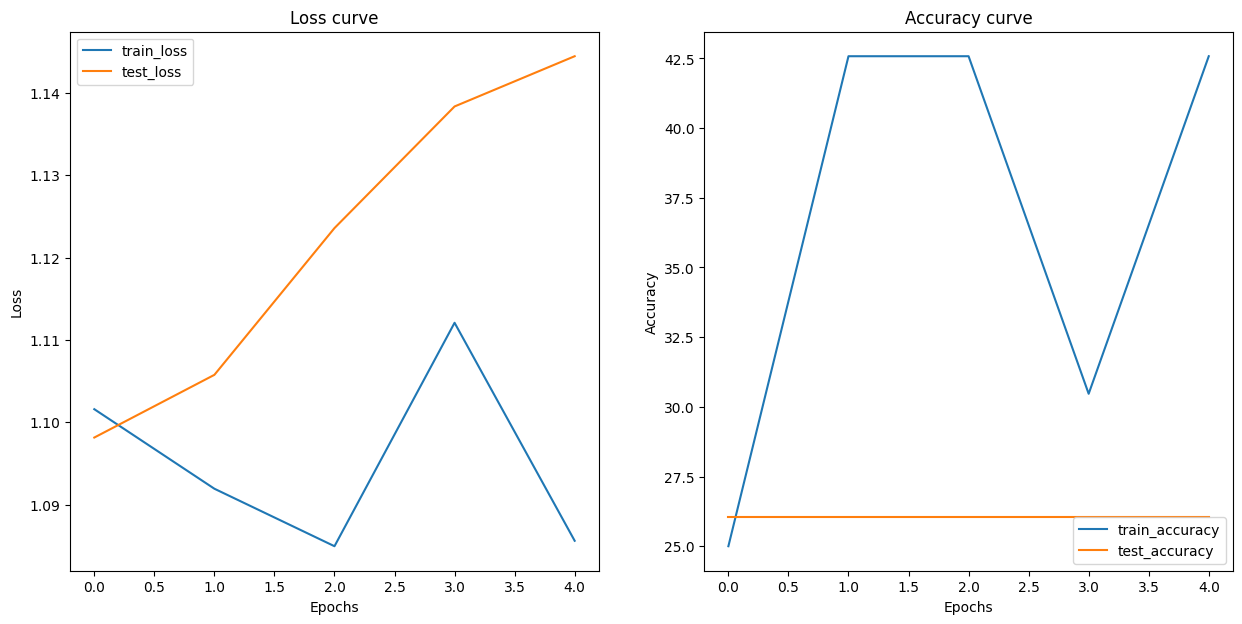

In [69]:
plot_loss_accuracy_curves(results=model_1_results)

## 10. Comparing model results

In [70]:
model_0_df = pd.DataFrame(model_0_results)
model_1_df = pd.DataFrame(model_1_results)
model_0_df

,train_loss,train_acc,test_loss,test_acc
0,1.105269,0.000000,1.092974,26.041667
1,1.088505,26.041667,1.084046,54.166667
2,1.078185,54.166667,1.074339,54.166667
3,1.066978,54.166667,1.063030,54.166667
4,1.053656,54.166667,1.049391,54.166667


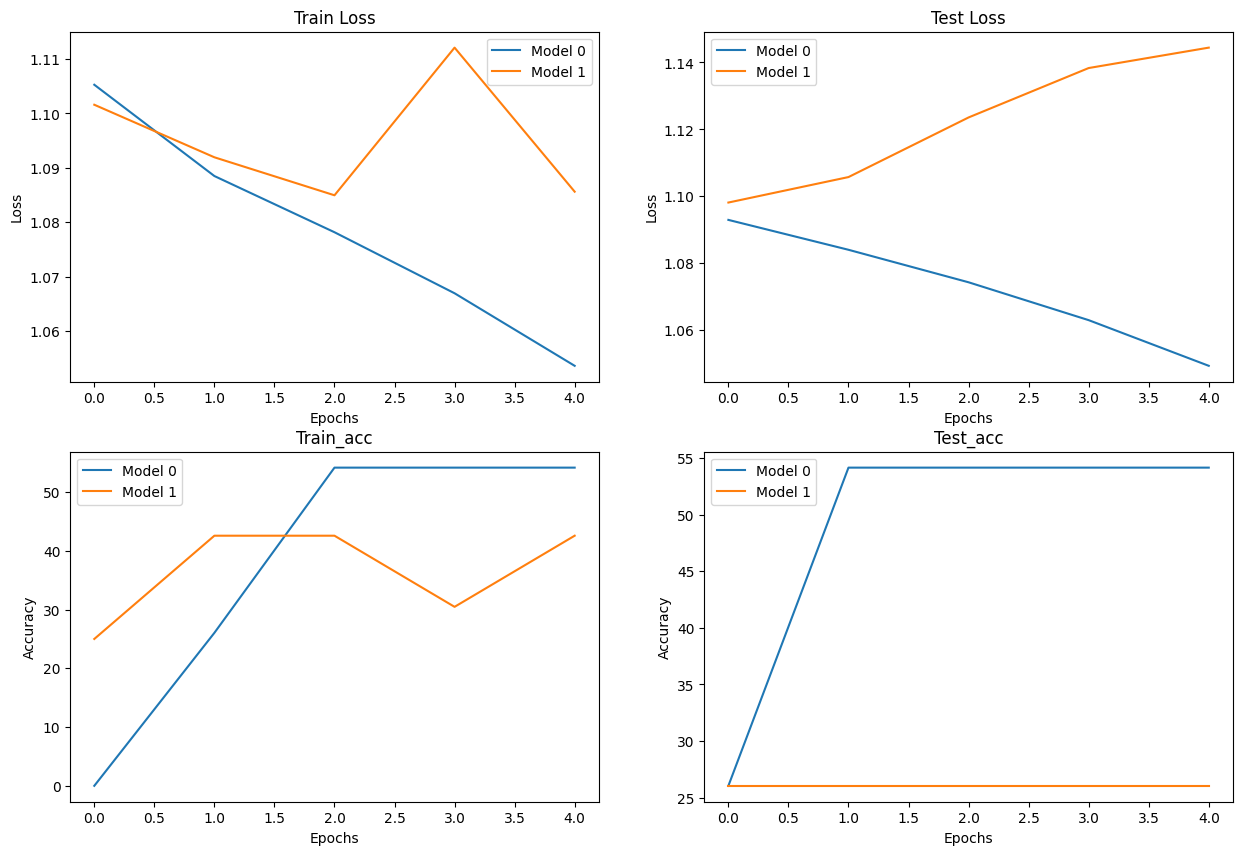

In [71]:
plt.figure(figsize=(15,10))
epochs=range(len(model_0_df))

plt.subplot(2,2,1)
plt.plot(epochs, model_0_df["train_loss"], label="Model 0")
plt.plot(epochs, model_1_df["train_loss"], label = "Model 1")
plt.title("Train Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(2,2,2)
plt.plot(epochs, model_0_df["test_loss"], label="Model 0")
plt.plot(epochs, model_1_df["test_loss"], label = "Model 1")
plt.title("Test Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(2,2,3)
plt.plot(epochs, model_0_df["train_acc"], label="Model 0")
plt.plot(epochs, model_1_df["train_acc"], label = "Model 1")
plt.title("Train_acc")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(2,2,4)
plt.plot(epochs, model_0_df["test_acc"], label="Model 0")
plt.plot(epochs, model_1_df["test_acc"], label = "Model 1")
plt.title("Test_acc")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

## 11. Making a prediction on a custom image

(Date - 9/June/2026)

In [72]:
custom_image_path = data_path/"04-pizza-daniel_dad.jpeg"
if not custom_image_path.is_file():
    with open(custom_image_path, "wb") as f:
        request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg")
        print(f"Downloading {custom_image_path}...")
        f.write(request.content)
else:
    print(f"{custom_image_path} already exists, skipping download")

### 11.1 Loading in a custom image

In [79]:
custom_image_uint8 = torchvision.io.read_image(str(custom_image_path))
print(f"Custom image tensor:\n{custom_image_uint8}\n\n")
print(f"Custom image shape: {custom_image_uint8.shape}")
print(f"Custom image dtype: {custom_image_uint8.dtype}")

Custom image tensor:
tensor([[[154, 173, 181,  ...,  21,  18,  14],
         [146, 165, 181,  ...,  21,  18,  15],
         [124, 146, 172,  ...,  18,  17,  15],
         ...,
         [ 72,  59,  45,  ..., 152, 150, 148],
         [ 64,  55,  41,  ..., 150, 147, 144],
         [ 64,  60,  46,  ..., 149, 146, 143]],

        [[171, 190, 193,  ...,  22,  19,  15],
         [163, 182, 193,  ...,  22,  19,  16],
         [141, 163, 184,  ...,  19,  18,  16],
         ...,
         [ 55,  42,  28,  ..., 107, 104, 103],
         [ 47,  38,  24,  ..., 108, 104, 102],
         [ 47,  43,  29,  ..., 107, 104, 101]],

        [[119, 138, 147,  ...,  17,  14,  10],
         [111, 130, 145,  ...,  17,  14,  11],
         [ 87, 111, 136,  ...,  14,  13,  11],
         ...,
         [ 35,  22,   8,  ...,  52,  52,  48],
         [ 27,  18,   4,  ...,  50,  49,  44],
         [ 27,  23,   9,  ...,  49,  46,  43]]], dtype=torch.uint8)


Custom image shape: torch.Size([3, 4032, 3024])
Custom image dty

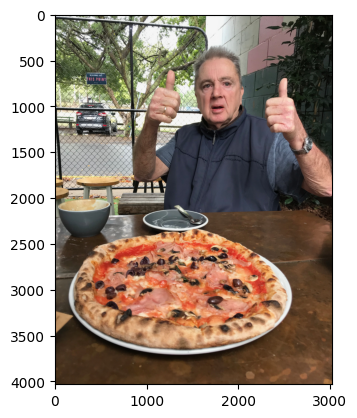

In [76]:
plt.imshow(custom_image_uint8.permute(1,2,0))

### 11.2 Making a prediction on a custom image with a trained model

In [ ]:
custom_image = torchvision.io.read_image(str(custom_image_path)).type(torch.float32) / 255.

custom_image_transform = transforms.Compose([
    transforms.Resize(size=(64,64))
])

custom_image_transformed = custom_image_transform(custom_image).unsqueeze(0) # Unsqueeze to add the batch size
print(f"Original shape: {custom_image.shape}\nTransformed shape: {custom_image_transformed.shape}")

model_1.eval()
with torch.inference_mode():
    custom_image_pred = model_1(custom_image_transformed.to(device))
    
print(f"Model 1 prediction: {custom_image_pred}")

Original shape: torch.Size([3, 4032, 3024])
Transformed shape: torch.Size([1, 3, 64, 64])
Model 1 prediction: tensor([[ 0.1163, -0.0406, -0.1722]])


In [90]:
custom_image_pred_probs = torch.softmax(custom_image_pred, dim=1)
custom_image_pred

tensor([[ 0.1163, -0.0406, -0.1722]])

In [91]:
custom_image_pred_label = torch.argmax(custom_image_pred_probs, dim=1)
custom_image_pred_label

tensor([0])

In [92]:
class_names[custom_image_pred_label]

'pizza'

### 11.3 Putting custom image prediction together: building a function

In [95]:
def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str,
                        class_names: List[str] = None,
                        transform=None,
                        device=device):
    """Makes a prediction on a target image and plots the image with its prediction."""
    target_image = torchvision.io.read_image(str(image_path)).type(torch.float32) / 255

    if transform is not None:
        target_image = transform(target_image)
    
    model.to(device)

    model.eval()
    with torch.inference_mode():
        target_image = target_image.unsqueeze(0)
        target_image_pred = model(target_image.to(device))
    
    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)
    target_image_pred_labels = torch.argmax(target_image_pred_probs, dim=1)

    plt.imshow(target_image.squeeze().permute(1,2,0))
    if class_names:
        title = f"Prediction : {class_names[target_image_pred_labels.cpu()]} | Probability : {target_image_pred_probs.max().cpu():.3f}"

    else:
        title = f"Prediction: {target_image_pred_labels} | Probability: {target_image_pred_probs.max().cpu():.3f}"
    
    plt.title(title)
    plt.axis("off")

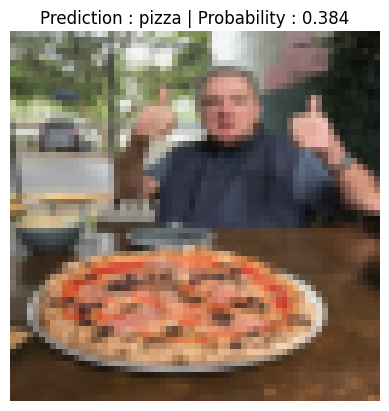

In [98]:
pred_and_plot_image(model=model_1,
                    image_path=custom_image_path,
                    class_names=class_names,
                    transform=custom_image_transform,
                    device=device)

**_Note_** : Although, the prediction is right, but it is still guessing. The prediction is not correct because our model is good, it's just a coincidence. See the probability of Pizza above (i.e. 0.384 out of 1.0). Try uploading more image, and you'll see.

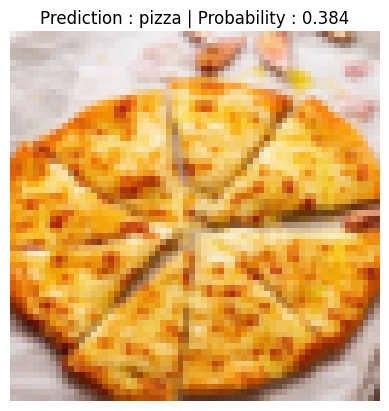

In [ ]:
pred_and_plot_image(model=model_1,
                    image_path="FoodData/Custom_images_for_testing/Custom_pizza_1.jfif",
                    class_names=class_names,
                    transform=custom_image_transform,
                    device=device)

It got right again?! I don't think so... Let's upload a custom Sushi image.